# Analysis of babylm evaluation-pipeline-2025 results

# Zero-shot Tasks

| Task | Description | Reference |
|------|-------------|-----------|
| **BLiMP** | Evaluates linguistic ability by identifying the grammatically correct sentence from minimally different pairs, testing various grammatical phenomena. | Warstadt et al., TACL 2020 |
| **BLiMP Supplement** | A supplement to BLiMP, focusing on dialogue and questions, introduced in the first BabyLM challenge. | Warstadt et al., CoNLL-BabyLM 2023 |
| **EWoK** | Similar to BLiMP but assesses the model's internal world knowledge, including physical and social knowledge. | Ivanova et al., 2024 |
| **Eye Tracking and Self-paced Reading** | Examines if the model mimics human eye tracking and reading time, using word surprisal as a proxy for time spent reading. | de Varda et al., BRM 2024 |
| **Entity Tracking** | Tests the model's ability to track changes in entity states as text or dialogue unfolds. | Kim & Schuster, ACL 2023 |
| **WUGs** | Evaluates morphological generalization in language models through an adjective nominalization task. | Hofmann et al., 2024 |

# Finetuning Tasks

| Task | Description | Reference |
|------|-------------|-----------|
| **BoolQ** | A yes/no question-answering dataset with unprompted and unconstrained questions. | Clark et al., NAACL 2019 |
| **MNLI** | The Multi-Genre Natural Language Inference corpus evaluates language understanding by testing a model's ability to recognize textual entailment. | Williams et al., NAACL 2018 |
| **MRPC** | The Microsoft Research Paraphrase Corpus contains sentence pairs that are either paraphrases/semantically equivalent or unrelated. | Dolan & Brockett, IJCNLP 2005 |
| **QQP** | The Quora Question Pairs corpus tests a model's ability to determine whether pairs of questions from Quora are semantically similar. | [Quora Dataset](https://www.quora.com/profile/Ricky-Riche-2/First-Quora-Dataset-Release-Question-Pairs) |
| **MultiRC** | The Multi-Sentence Reading Comprehension corpus is a QA task modified for binary classification, judging whether an answer to a question-context pair is correct. | Khashabi et al., NAACL 2018 |
| **RTE** | The Recognizing Textual Entailment task tests a model's ability to recognize textual entailment. | Dagan et al., Springer 2006; Bar et al., 2006; Giampiccolo et al., 2007; Bentivogli et al., TAC 2009 |
| **WSC** | The Winograd Schema Challenge evaluates coreference resolution, modified as a binary classification task with a pronoun and noun phrase. | Levesque et al., PKRR 2012 |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

NumPy version: 2.2.5
Matplotlib version: 3.10.6


## GPT2

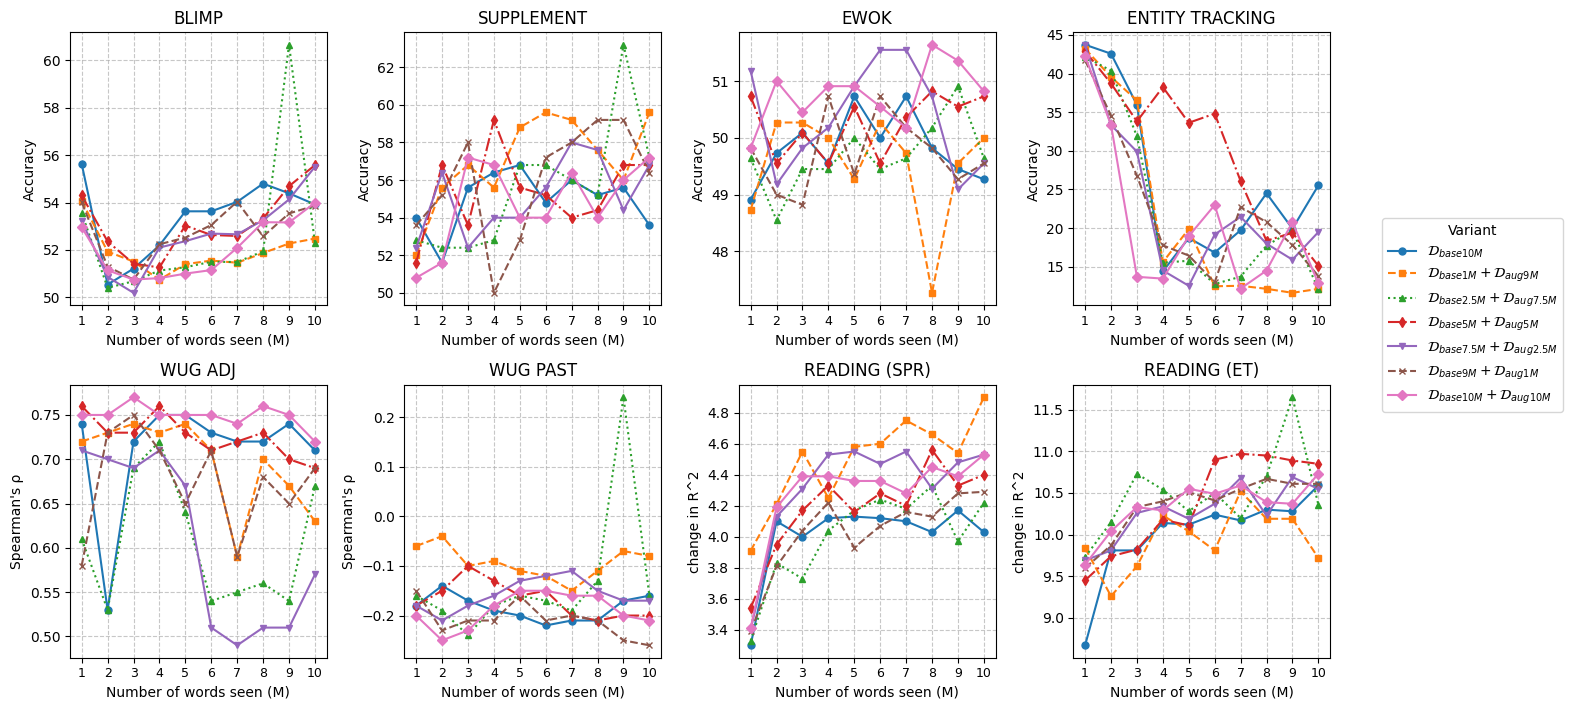

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

models = [
    "babylm-base10m-gpt2",
    "babylm-base1m-gpt2",
    "babylm-base2f5m-gpt2",
    "babylm-base5m-gpt2",
    "babylm-base7f5m-gpt2",
    "babylm-base9m-gpt2",
    "babylm-rta10m-gpt2",
]

dfs = {}
revisions_to_include = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
base_path = '../evaluation-pipeline-2025/results/'

for model in models:
    csv_path = base_path + model + '/fastzeroshot_results_causal.csv'
    df = pd.read_csv(csv_path)
    df['Revision_num'] = df['REVISION'].str.extract(r'chck_(\d+)M').astype(int)
    df_filtered = df[df['Revision_num'].isin(revisions_to_include)]
    df_filtered = df_filtered.sort_values('Revision_num')
    dfs[model] = df_filtered

metric_names = ['BLIMP', 'SUPPLEMENT', 'EWOK', 'ENTITY TRACKING', 'WUG ADJ', 'WUG PAST', 'READING (SPR)', 'READING (ET)']
metric_types = ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', "Spearman's ρ", "Spearman's ρ", 'change in R^2', 'change in R^2']
labels = [
    r'$\mathcal{D}_{base10M}$',
    r'$\mathcal{D}_{base1M}+\mathcal{D}_{aug9M}$',
    r'$\mathcal{D}_{base2.5M}+\mathcal{D}_{aug7.5M}$',
    r'$\mathcal{D}_{base5M}+\mathcal{D}_{aug5M}$',
    r'$\mathcal{D}_{base7.5M}+\mathcal{D}_{aug2.5M}$',
    r'$\mathcal{D}_{base9M}+\mathcal{D}_{aug1M}$',
    r'$\mathcal{D}_{base10M}+\mathcal{D}_{aug10M}$'
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

handles = []
labels_legend = []

for idx, (metric_name, metric_type) in enumerate(zip(metric_names, metric_types)):
    ax = axes[idx]
    for model_idx, model in enumerate(models):
        df = dfs[model]
        line = ax.plot(
            df['Revision_num'], 
            df[metric_name], 
            marker=['o', 's', '^', 'd', 'v', 'x', 'D'][model_idx],
            linestyle=['-', '--', ':', '-.', '-', '--', '-'][model_idx],
            color=plt.get_cmap('tab10').colors[model_idx],
            markersize=5, 
            label=labels[model_idx]
        )
        if idx == 0:
            handles.extend(line)
            labels_legend.append(labels[model_idx])
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel(metric_type, fontsize=10)
    ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    ax.set_xlabel('Number of words seen (M)')
    ax.set_xticklabels(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(handles, labels_legend, loc='right', ncol=1, title='Variant', fontsize=10, bbox_to_anchor=(1.05, 0.5))

plt.tight_layout(rect=[0, 0, 0.90, 0.90])
plt.savefig('fast_zeroshot_gpt2_linegraph_1-10.svg', format='svg', bbox_inches='tight')
plt.show()

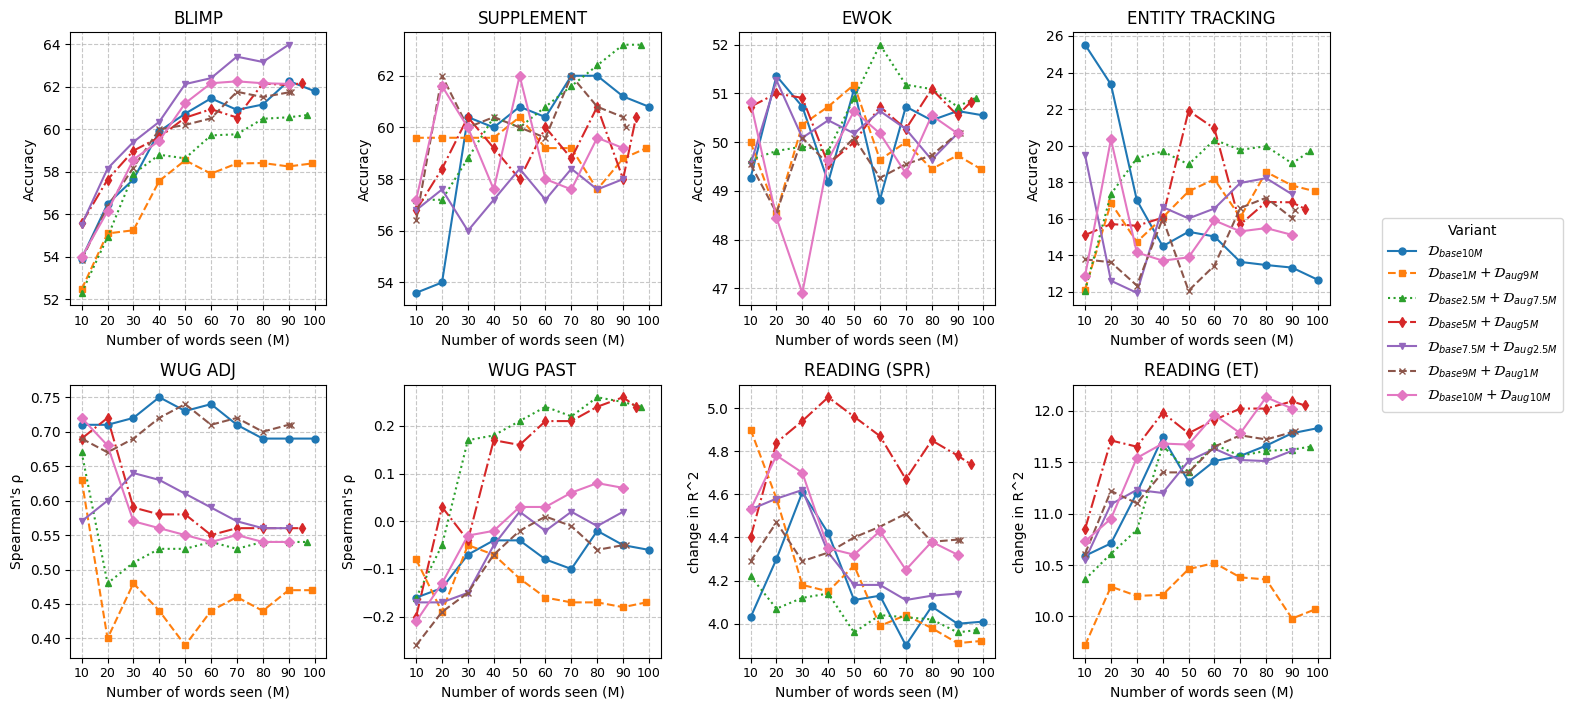

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

models = [
    "babylm-base10m-gpt2",
    "babylm-base1m-gpt2",
    "babylm-base2f5m-gpt2",
    "babylm-base5m-gpt2",
    "babylm-base7f5m-gpt2",
    "babylm-base9m-gpt2",
    "babylm-rta10m-gpt2",
]

dfs = {}
revisions_to_include = [10, 20, 30, 40, 50, 60, 70, 80, 90, 91, 92, 95, 97, 99, 100]
base_path = '../evaluation-pipeline-2025/results/'

for model in models:
    csv_path = base_path + model + '/fastzeroshot_results_causal.csv'
    df = pd.read_csv(csv_path)
    df['Revision_num'] = df['REVISION'].str.extract(r'chck_(\d+)M').astype(int)
    df_filtered = df[df['Revision_num'].isin(revisions_to_include)]
    df_filtered = df_filtered.sort_values('Revision_num')
    dfs[model] = df_filtered

metric_names = ['BLIMP', 'SUPPLEMENT', 'EWOK', 'ENTITY TRACKING', 'WUG ADJ', 'WUG PAST', 'READING (SPR)', 'READING (ET)']
metric_types = ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', "Spearman's ρ", "Spearman's ρ", 'change in R^2', 'change in R^2']
labels = [
    r'$\mathcal{D}_{base10M}$',
    r'$\mathcal{D}_{base1M}+\mathcal{D}_{aug9M}$',
    r'$\mathcal{D}_{base2.5M}+\mathcal{D}_{aug7.5M}$',
    r'$\mathcal{D}_{base5M}+\mathcal{D}_{aug5M}$',
    r'$\mathcal{D}_{base7.5M}+\mathcal{D}_{aug2.5M}$',
    r'$\mathcal{D}_{base9M}+\mathcal{D}_{aug1M}$',
    r'$\mathcal{D}_{base10M}+\mathcal{D}_{aug10M}$'
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

handles = []
labels_legend = []

for idx, (metric_name, metric_type) in enumerate(zip(metric_names, metric_types)):
    ax = axes[idx]
    for model_idx, model in enumerate(models):
        df = dfs[model]
        line = ax.plot(
            df['Revision_num'], 
            df[metric_name], 
            marker=['o', 's', '^', 'd', 'v', 'x', 'D'][model_idx],
            linestyle=['-', '--', ':', '-.', '-', '--', '-'][model_idx],
            color=plt.get_cmap('tab10').colors[model_idx],
            markersize=5, 
            label=labels[model_idx]
        )
        if idx == 0:
            handles.extend(line)
            labels_legend.append(labels[model_idx])
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel(metric_type, fontsize=10)
    ax.set_xticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    ax.set_xlabel('Number of words seen (M)')
    ax.set_xticklabels(['10', '20', '30', '40', '50', '60', '70', '80', '90', '100'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(handles, labels_legend, loc='right', ncol=1, title='Variant', fontsize=10, bbox_to_anchor=(1.05, 0.5))

plt.tight_layout(rect=[0, 0, 0.90, 0.90])
plt.savefig('fast_zeroshot_gpt2_linegraph_10-100.svg', format='svg', bbox_inches='tight')
plt.show()

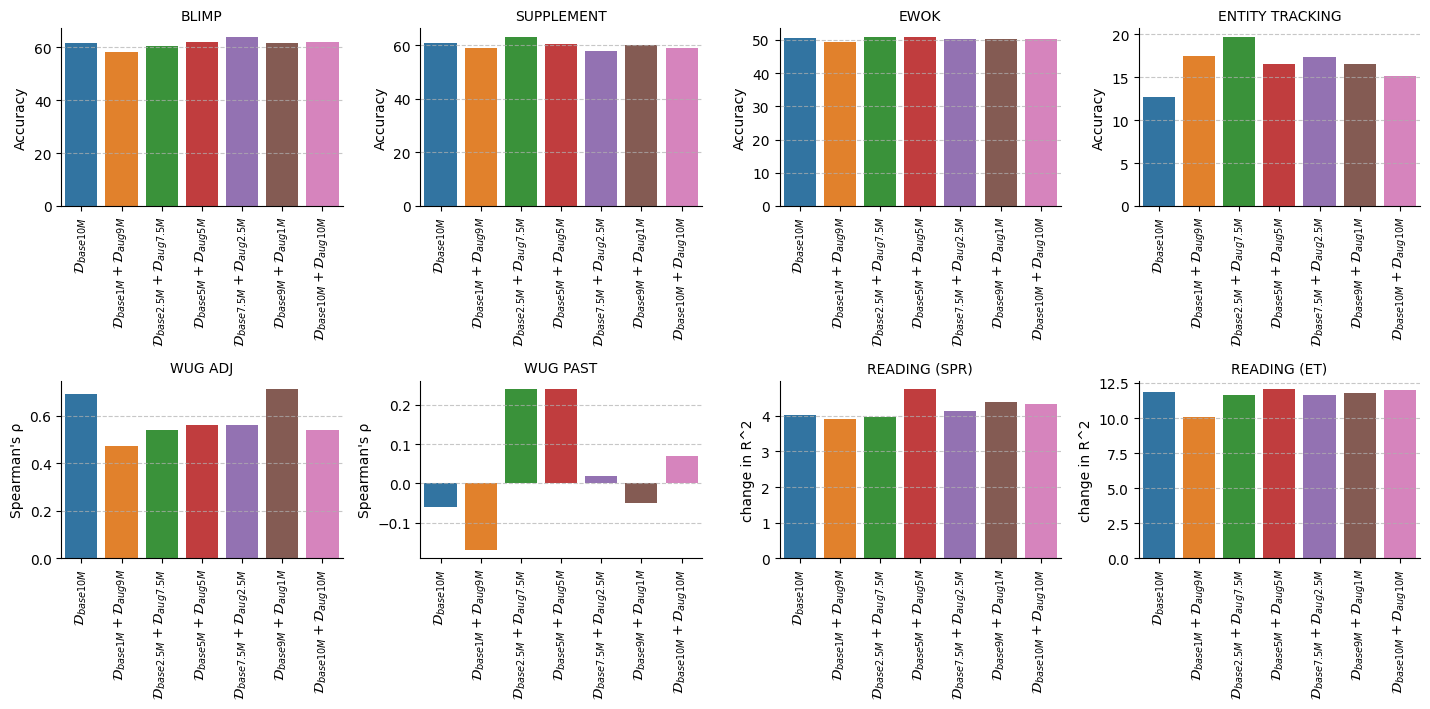

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

models = [
    "babylm-base10m-gpt2",
    "babylm-base1m-gpt2",
    "babylm-base2f5m-gpt2",
    "babylm-base5m-gpt2",
    "babylm-base7f5m-gpt2",
    "babylm-base9m-gpt2",
    "babylm-rta10m-gpt2",
]

labels = [
    r'$\mathcal{D}_{base10M}$',
    r'$\mathcal{D}_{base1M}+\mathcal{D}_{aug9M}$',
    r'$\mathcal{D}_{base2.5M}+\mathcal{D}_{aug7.5M}$',
    r'$\mathcal{D}_{base5M}+\mathcal{D}_{aug5M}$',
    r'$\mathcal{D}_{base7.5M}+\mathcal{D}_{aug2.5M}$',
    r'$\mathcal{D}_{base9M}+\mathcal{D}_{aug1M}$',
    r'$\mathcal{D}_{base10M}+\mathcal{D}_{aug10M}$'
]

model_to_label = dict(zip(models, labels))

revisions_to_include = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 91, 92, 95, 97, 99, 100]
base_path = '../evaluation-pipeline-2025/results/'

dfs = {}
for model in models:
    csv_path = base_path + model + '/fastzeroshot_results_causal.csv'
    df = pd.read_csv(csv_path)
    df['Revision_num'] = df['REVISION'].str.extract(r'chck_(\d+)M').astype(int)
    df_filtered = df[df['Revision_num'].isin(revisions_to_include)]
    df_filtered = df_filtered.sort_values('Revision_num')
    df_filtered['Variant'] = model_to_label[model]
    dfs[model] = df_filtered

combined_df = pd.concat(dfs.values(), ignore_index=True)

metric_names = ['BLIMP', 'SUPPLEMENT', 'EWOK', 'ENTITY TRACKING', 'WUG ADJ', 'WUG PAST', 'READING (SPR)', 'READING (ET)']
metric_types = ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', "Spearman's ρ", "Spearman's ρ", 'change in R^2', 'change in R^2']
metric_to_type = dict(zip(metric_names, metric_types))

final_df = combined_df.loc[combined_df.groupby('Variant')['Revision_num'].idxmax()]
final_melted = pd.melt(final_df, id_vars=['Variant'], value_vars=metric_names, var_name='Task', value_name='Metric')

final_melted['Variant'] = pd.Categorical(final_melted['Variant'], categories=labels, ordered=True)
final_melted = final_melted.sort_values('Variant')

g = sns.FacetGrid(final_melted, col='Task', col_order=metric_names, col_wrap=4, height=4, aspect=1.0, sharey=False, sharex=False)
g.map_dataframe(sns.barplot, 'Variant', 'Metric', hue='Variant', order=labels, palette='tab10', legend=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Metric Value')

for ax, task in zip(g.axes.flat, g.col_names):
    metric_type = metric_to_type.get(task, 'Metric Value')
    ax.set_ylabel(metric_type)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, ha='center')

plt.tight_layout(rect=[0, 0, 0.90, 0.90])
plt.savefig('fast_zeroshot_gpt2_barchart.svg', format='svg', bbox_inches='tight')
plt.show()

## RoBERTa

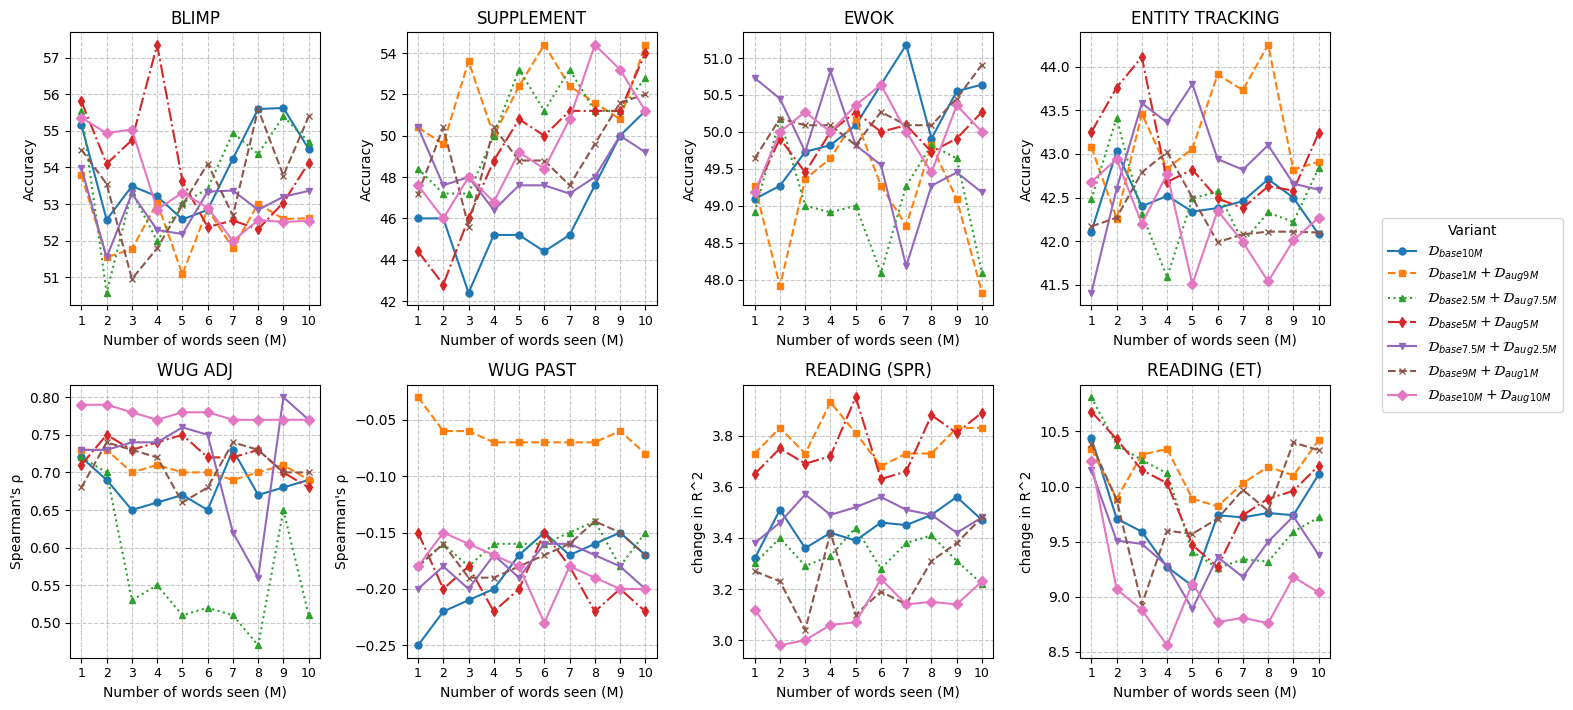

In [13]:

import pandas as pd
import matplotlib.pyplot as plt

models = [
    "babylm-base10m-roberta",
    "babylm-base1m-roberta",
    "babylm-base2f5m-roberta",
    "babylm-base5m-roberta",
    "babylm-base7f5m-roberta",
    "babylm-base9m-roberta",
    "babylm-rta10m-roberta",
]

dfs = {}
revisions_to_include = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
base_path = '../evaluation-pipeline-2025/results/'

for model in models:
    csv_path = base_path + model + '/fastzeroshot_results_mlm.csv'
    df = pd.read_csv(csv_path)
    df['Revision_num'] = df['REVISION'].str.extract(r'chck_(\d+)M').astype(int)
    df_filtered = df[df['Revision_num'].isin(revisions_to_include)]
    df_filtered = df_filtered.sort_values('Revision_num')
    dfs[model] = df_filtered

metric_names = ['BLIMP', 'SUPPLEMENT', 'EWOK', 'ENTITY TRACKING', 'WUG ADJ', 'WUG PAST', 'READING (SPR)', 'READING (ET)']
metric_types = ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', "Spearman's ρ", "Spearman's ρ", 'change in R^2', 'change in R^2']
labels = [
    r'$\mathcal{D}_{base10M}$',
    r'$\mathcal{D}_{base1M}+\mathcal{D}_{aug9M}$',
    r'$\mathcal{D}_{base2.5M}+\mathcal{D}_{aug7.5M}$',
    r'$\mathcal{D}_{base5M}+\mathcal{D}_{aug5M}$',
    r'$\mathcal{D}_{base7.5M}+\mathcal{D}_{aug2.5M}$',
    r'$\mathcal{D}_{base9M}+\mathcal{D}_{aug1M}$',
    r'$\mathcal{D}_{base10M}+\mathcal{D}_{aug10M}$'
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

handles = []
labels_legend = []

for idx, (metric_name, metric_type) in enumerate(zip(metric_names, metric_types)):
    ax = axes[idx]
    for model_idx, model in enumerate(models):
        df = dfs[model]
        line = ax.plot(
            df['Revision_num'], 
            df[metric_name], 
            marker=['o', 's', '^', 'd', 'v', 'x', 'D'][model_idx],
            linestyle=['-', '--', ':', '-.', '-', '--', '-'][model_idx],
            color=plt.get_cmap('tab10').colors[model_idx],
            markersize=5, 
            label=labels[model_idx]
        )
        if idx == 0:
            handles.extend(line)
            labels_legend.append(labels[model_idx])
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel(metric_type, fontsize=10)
    ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    ax.set_xlabel('Number of words seen (M)')
    ax.set_xticklabels(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(handles, labels_legend, loc='right', ncol=1, title='Variant', fontsize=10, bbox_to_anchor=(1.05, 0.5))

plt.tight_layout(rect=[0, 0, 0.90, 0.90])
plt.savefig('fast_zeroshot_roberta_linegraph_1-10.svg', format='svg', bbox_inches='tight')
plt.show()

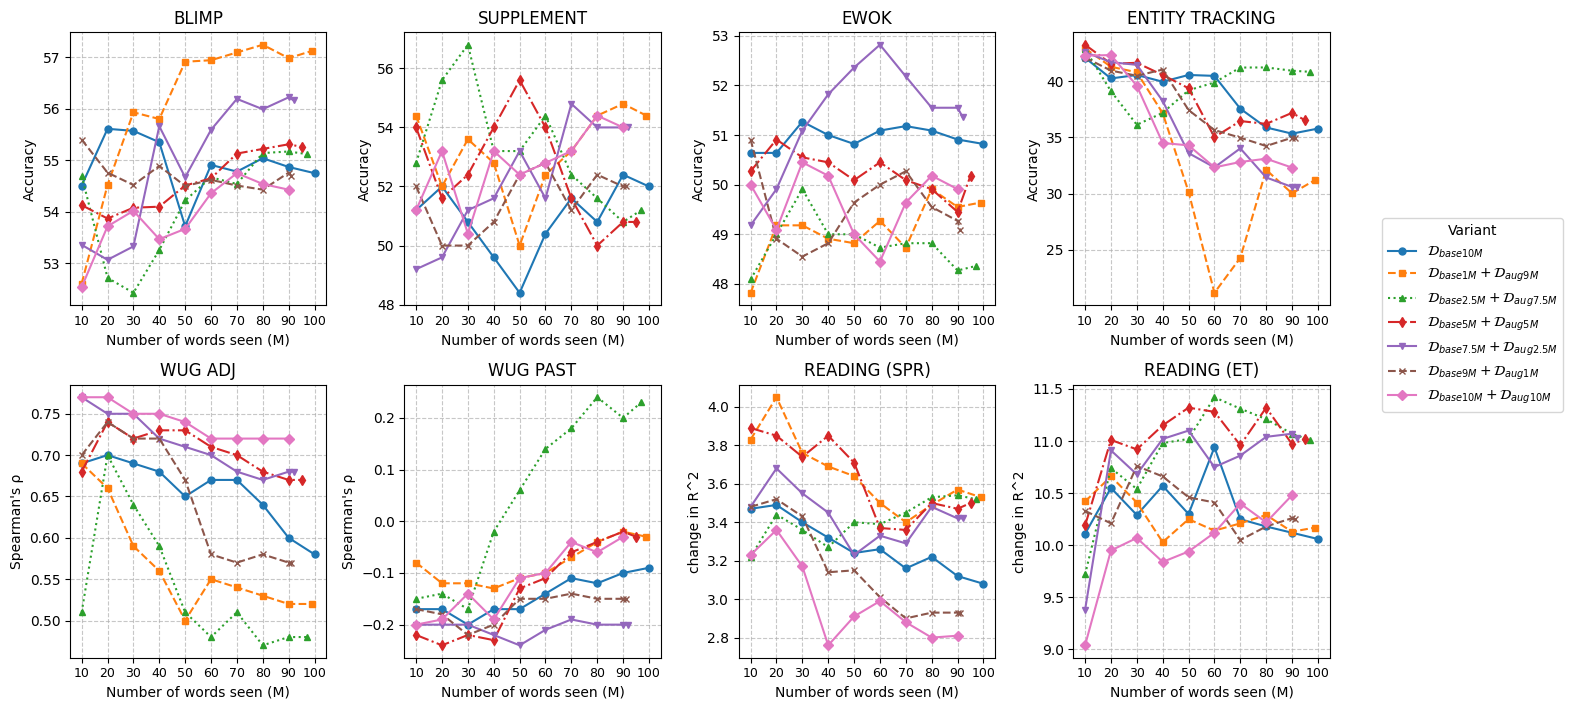

In [14]:

import pandas as pd
import matplotlib.pyplot as plt

models = [
    "babylm-base10m-roberta",
    "babylm-base1m-roberta",
    "babylm-base2f5m-roberta",
    "babylm-base5m-roberta",
    "babylm-base7f5m-roberta",
    "babylm-base9m-roberta",
    "babylm-rta10m-roberta",
]

dfs = {}
revisions_to_include = [10, 20, 30, 40, 50, 60, 70, 80, 90, 91, 92, 95, 97, 99, 100]
base_path = '../evaluation-pipeline-2025/results/'

for model in models:
    csv_path = base_path + model + '/fastzeroshot_results_mlm.csv'
    df = pd.read_csv(csv_path)
    df['Revision_num'] = df['REVISION'].str.extract(r'chck_(\d+)M').astype(int)
    df_filtered = df[df['Revision_num'].isin(revisions_to_include)]
    df_filtered = df_filtered.sort_values('Revision_num')
    dfs[model] = df_filtered

metric_names = ['BLIMP', 'SUPPLEMENT', 'EWOK', 'ENTITY TRACKING', 'WUG ADJ', 'WUG PAST', 'READING (SPR)', 'READING (ET)']
metric_types = ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', "Spearman's ρ", "Spearman's ρ", 'change in R^2', 'change in R^2']
labels = [
    r'$\mathcal{D}_{base10M}$',
    r'$\mathcal{D}_{base1M}+\mathcal{D}_{aug9M}$',
    r'$\mathcal{D}_{base2.5M}+\mathcal{D}_{aug7.5M}$',
    r'$\mathcal{D}_{base5M}+\mathcal{D}_{aug5M}$',
    r'$\mathcal{D}_{base7.5M}+\mathcal{D}_{aug2.5M}$',
    r'$\mathcal{D}_{base9M}+\mathcal{D}_{aug1M}$',
    r'$\mathcal{D}_{base10M}+\mathcal{D}_{aug10M}$'
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

handles = []
labels_legend = []

for idx, (metric_name, metric_type) in enumerate(zip(metric_names, metric_types)):
    ax = axes[idx]
    for model_idx, model in enumerate(models):
        df = dfs[model]
        line = ax.plot(
            df['Revision_num'], 
            df[metric_name], 
            marker=['o', 's', '^', 'd', 'v', 'x', 'D'][model_idx],
            linestyle=['-', '--', ':', '-.', '-', '--', '-'][model_idx],
            color=plt.get_cmap('tab10').colors[model_idx],
            markersize=5, 
            label=labels[model_idx]
        )
        if idx == 0:
            handles.extend(line)
            labels_legend.append(labels[model_idx])
    ax.set_title(metric_name, fontsize=12)
    ax.set_ylabel(metric_type, fontsize=10)
    ax.set_xticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    ax.set_xlabel('Number of words seen (M)')
    ax.set_xticklabels(['10', '20', '30', '40', '50', '60', '70', '80', '90', '100'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(handles, labels_legend, loc='right', ncol=1, title='Variant', fontsize=10, bbox_to_anchor=(1.05, 0.5))

plt.tight_layout(rect=[0, 0, 0.90, 0.90])
plt.savefig('fast_zeroshot_roberta_linegraph_10-100.svg', format='svg', bbox_inches='tight')
plt.show()

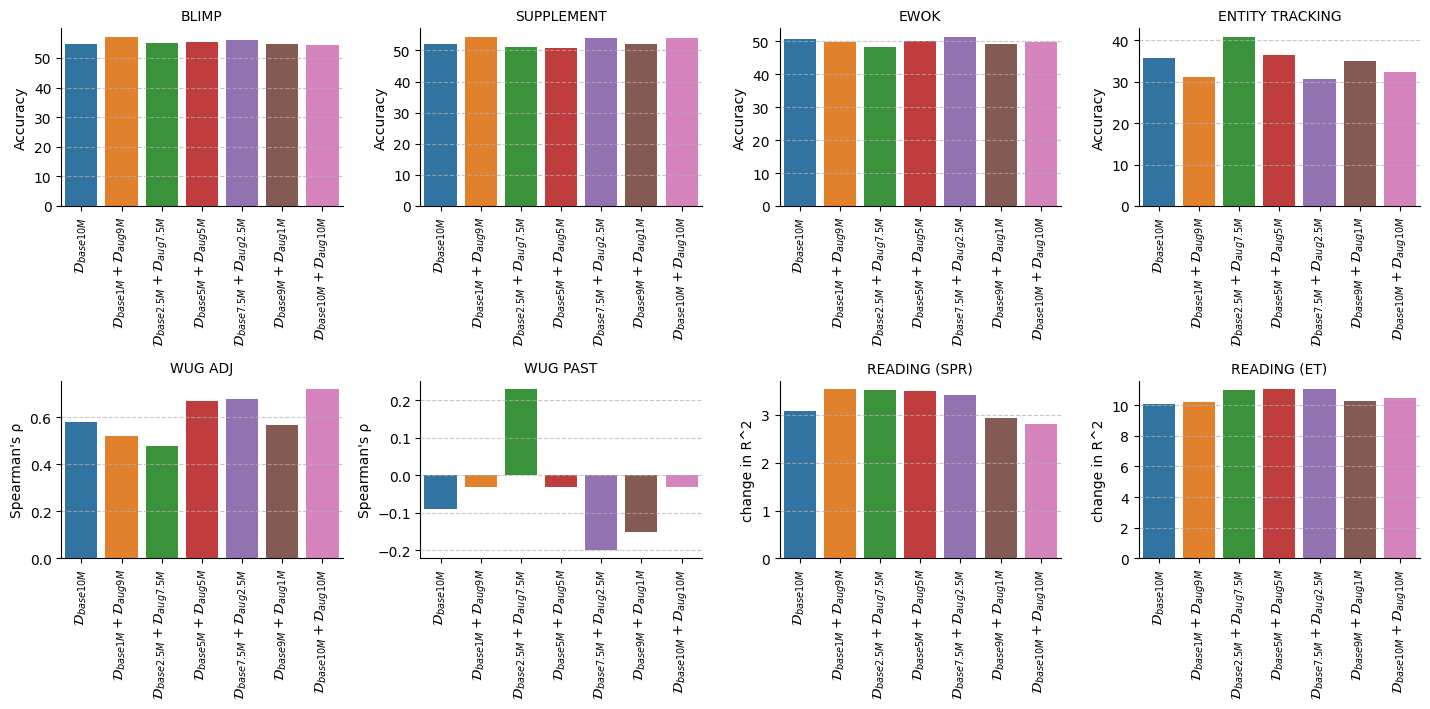

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

models = [
    "babylm-base10m-roberta",
    "babylm-base1m-roberta",
    "babylm-base2f5m-roberta",
    "babylm-base5m-roberta",
    "babylm-base7f5m-roberta",
    "babylm-base9m-roberta",
    "babylm-rta10m-roberta",
]

labels = [
    r'$\mathcal{D}_{base10M}$',
    r'$\mathcal{D}_{base1M}+\mathcal{D}_{aug9M}$',
    r'$\mathcal{D}_{base2.5M}+\mathcal{D}_{aug7.5M}$',
    r'$\mathcal{D}_{base5M}+\mathcal{D}_{aug5M}$',
    r'$\mathcal{D}_{base7.5M}+\mathcal{D}_{aug2.5M}$',
    r'$\mathcal{D}_{base9M}+\mathcal{D}_{aug1M}$',
    r'$\mathcal{D}_{base10M}+\mathcal{D}_{aug10M}$'
]

model_to_label = dict(zip(models, labels))

revisions_to_include = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 91, 92, 95, 97, 99, 100]
base_path = '../evaluation-pipeline-2025/results/'

dfs = {}
for model in models:
    csv_path = base_path + model + '/fastzeroshot_results_mlm.csv'
    df = pd.read_csv(csv_path)
    df['Revision_num'] = df['REVISION'].str.extract(r'chck_(\d+)M').astype(int)
    df_filtered = df[df['Revision_num'].isin(revisions_to_include)]
    df_filtered = df_filtered.sort_values('Revision_num')
    df_filtered['Variant'] = model_to_label[model]
    dfs[model] = df_filtered

combined_df = pd.concat(dfs.values(), ignore_index=True)

metric_names = ['BLIMP', 'SUPPLEMENT', 'EWOK', 'ENTITY TRACKING', 'WUG ADJ', 'WUG PAST', 'READING (SPR)', 'READING (ET)']
metric_types = ['Accuracy', 'Accuracy', 'Accuracy', 'Accuracy', "Spearman's ρ", "Spearman's ρ", 'change in R^2', 'change in R^2']
metric_to_type = dict(zip(metric_names, metric_types))

final_df = combined_df.loc[combined_df.groupby('Variant')['Revision_num'].idxmax()]
final_melted = pd.melt(final_df, id_vars=['Variant'], value_vars=metric_names, var_name='Task', value_name='Metric')

final_melted['Variant'] = pd.Categorical(final_melted['Variant'], categories=labels, ordered=True)
final_melted = final_melted.sort_values('Variant')

g = sns.FacetGrid(final_melted, col='Task', col_order=metric_names, col_wrap=4, height=4, aspect=1.0, sharey=False, sharex=False)
g.map_dataframe(sns.barplot, 'Variant', 'Metric', hue='Variant', order=labels, palette='tab10', legend=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Metric Value')

for ax, task in zip(g.axes.flat, g.col_names):
    metric_type = metric_to_type.get(task, 'Metric Value')
    ax.set_ylabel(metric_type)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, ha='center')

plt.tight_layout(rect=[0, 0, 0.90, 0.90])
plt.savefig('fast_zeroshot_roberta_barchart.svg', format='svg', bbox_inches='tight')
plt.show()